# Combine scenarios in one figure

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import xarray as xr
from functions import read_netCDF_xr


# Uncomment for interactive plots:
%matplotlib widget 

### Load the data from all scenarios

In [47]:
data_constant=read_netCDF_xr(os.path.join("Results","constant_scenario.nc"))
data_periodic=read_netCDF_xr(os.path.join("Results","periodic_scenario.nc"))
data_simulations=read_netCDF_xr(os.path.join("Results","simulations.nc"))

### Compute average and std for the Monte-Carlo simulations

In [48]:
hepi_sim_mean=data_simulations.hepi.mean(dim="simulation")
hepi_sim_std=data_simulations.hepi.std(dim="simulation")
Cepi_sim_mean=data_simulations.Cepi.mean(dim="simulation")
Cepi_sim_std=data_simulations.Cepi.std(dim="simulation")
Chypo_sim_mean=data_simulations.Chypo.mean(dim="simulation")
Chypo_sim_std=data_simulations.Chypo.std(dim="simulation")

### Figure

In [49]:
C_thresh=0.1 # [ug/l]

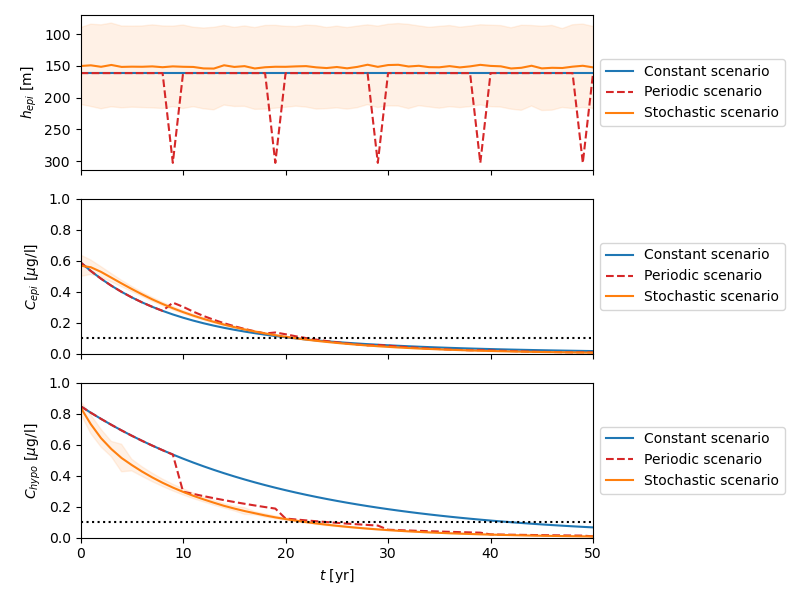

In [54]:
fig,ax=plt.subplots(3,1,figsize=(8,6),sharex=True)

ax[0].plot(data_constant.time,data_constant.hepi[0,:],color='C0',linestyle='-',label="Constant scenario")
ax[0].plot(data_periodic.time,data_periodic.hepi[0,:],color='C3',linestyle='--',label="Periodic scenario")
ax[0].plot(data_simulations.time,hepi_sim_mean,linestyle='-',color='C1',label="Stochastic scenario")
ax[0].fill_between(x=data_simulations.time,y1=hepi_sim_mean-hepi_sim_std,y2=hepi_sim_mean+hepi_sim_std,linestyle='-',color='C1',alpha=0.1)
ax[0].set_ylabel("$h_{epi}$ [m]")
ax[0].legend(bbox_to_anchor=(1,0.5),loc="center left")
ax[0].invert_yaxis()

ax[1].plot(data_constant.time,data_constant.Cepi[0,:],color='C0',linestyle='-',label="Constant scenario")
ax[1].plot(data_periodic.time,data_periodic.Cepi[0,:],color='C3',linestyle='--',label="Periodic scenario")
ax[1].plot(data_simulations.time,Cepi_sim_mean,linestyle='-',color='C1',label="Stochastic scenario")
ax[1].fill_between(x=data_simulations.time,y1=Cepi_sim_mean-Cepi_sim_std,y2=Cepi_sim_mean+Cepi_sim_std,linestyle='-',color='C1',alpha=0.1)
ax[1].plot(data_constant.time[[0,-1]],C_thresh*np.full((2,),1),':k')
ax[1].set_ylim([0,1])
ax[1].set_ylabel("$C_{epi}$ [$\mu$g/l]")
ax[1].legend(bbox_to_anchor=(1,0.5),loc="center left")

ax[2].plot(data_constant.time,data_constant.Chypo[0,:],color='C0',linestyle='-',label="Constant scenario")
ax[2].plot(data_periodic.time,data_periodic.Chypo[0,:],color='C3',linestyle='--',label="Periodic scenario")
ax[2].plot(data_simulations.time,Chypo_sim_mean,linestyle='-',color='C1',label="Stochastic scenario")
ax[2].fill_between(x=data_simulations.time,y1=Chypo_sim_mean-Chypo_sim_std,y2=Chypo_sim_mean+Chypo_sim_std,linestyle='-',color='C1',alpha=0.1)
ax[2].plot(data_constant.time[[0,-1]],C_thresh*np.full((2,),1),':k')
ax[2].set_ylim([0,1])
ax[2].set_xlabel("$t$ [yr]")
ax[2].set_ylabel("$C_{hypo}$ [$\mu$g/l]")
ax[2].legend(bbox_to_anchor=(1,0.5),loc="center left")

ax[0].set_xlim([0,50])

fig.set_tight_layout(True)

Save figure

In [56]:
fig.savefig(os.path.join("Figures","triazole_residence_time_combined.png"),dpi=400)
print("Figure saved!")

Figure saved!
